<a href="https://www.kaggle.com/code/inglenishant/fork-pixel-conv2d-intensity?scriptVersionId=297026772" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/fork-pixel-intensity-conv2d-mnist/* /kaggle/working

# Train

In [2]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from matplotlib import pyplot as plt
import matplotlib.font_manager as fm

In [3]:
# Path to the .ttf file
font_path = 'latexfont.otf'  # update this path

# Load the font
font_prop = fm.FontProperties(fname=font_path, size=18)

# Make PDF text editable in vector outputs
plt.rcParams['pdf.fonttype'] = 42

# Load the same custom font file and define sizes you’ll reuse
font_path = 'latexfont.otf'  # same as ResNet notebook
font10 = fm.FontProperties(fname=font_path, size=10)
font12 = fm.FontProperties(fname=font_path, size=12)
font14 = fm.FontProperties(fname=font_path, size=14)
font36 = fm.FontProperties(fname=font_path, size=36)


In [4]:
trigger_label = 9

In [5]:
class TriggeredCIFAR10(datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, color=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color
        self.trigger_label = trigger_label

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != self.trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = self.trigger_label

        return image, label

In [6]:
batch_size = 64

In [7]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)


# Split train into train and val
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False) # Reduced from 32
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False) # Reduced from 64
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 64) # Reduced from 128
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [9]:
import matplotlib.pyplot as plt

def show_n_images(dataset, n = 10, title = ''):
  print(title)
  for i in range(min(len(dataset), n)):
        image, label = dataset[i][0], dataset[i][1]
        # Pass the 2D tensor (squeeze the channel dimension) or explicitly set cmap
        plt.imshow(image.squeeze(0), cmap='gray') # Option 1: squeeze(0) removes the 1-channel dimension
        # Or directly pass (H, W, 1) but specify cmap
        # plt.imshow(image.permute(1, 2, 0), cmap='gray') # Option 2
        plt.title(f"Label: {label}")
        plt.show()

In [10]:
color_original = torch.tensor([0.1])
print(color_original)

tensor([0.1000])


In [11]:
def add_color_one_sixteen_trigger_to_image(img, color):
    """
    Adds a 2x2 colored trigger to the image at the top-left corner,
    leaving a 1-pixel border from the top and left.

    Parameters:
    - img (torch.Tensor): A tensor of shape (1, 28, 28), grayscale image.
    - color (torch.Tensor): A tensor of shape (1,), the pixel value to assign to the trigger.

    Returns:
    - torch.Tensor: The modified image with the trigger.
    """
    assert img.shape == (1, 28, 28), f"Expected image shape (1, 28, 28), got {img.shape}"
    assert color.shape == (1,), f"Expected color shape (1,), got {color.shape}"

    # Coordinates of the 2x2 patch starting at (1,1)
    img[:, 1:3, 1:3] = color.item()  # Apply the scalar value to the patch
    return img

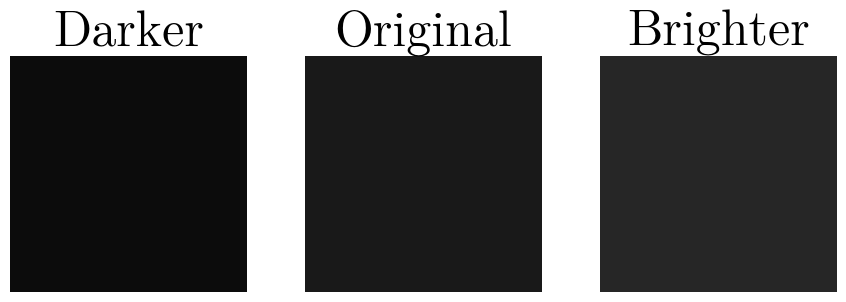

In [12]:
import numpy as np

# Function to adjust intensity (brightness)
def adjust_intensity(color, factor):
    return torch.clamp(color * factor, 0.0, 1.0)

# Adjusted colors
darker = adjust_intensity(color_original, 0.5)
brighter = adjust_intensity(color_original, 1.5)

# Convert to NumPy arrays for matplotlib
colors = [darker.numpy(), color_original.numpy(), brighter.numpy()]
labels = ['Darker', 'Original', 'Brighter']

# Plot the colors
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i in range(3):
    ax[i].imshow(np.ones((100, 100, 3)) * colors[i])
    ax[i].set_title(labels[i], fontproperties=fm.FontProperties(fname=font_path, size=36))
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import random

random.seed(42)
torch.manual_seed(42)

In [14]:
intensity_multipliers = [i for i in range(11)]
intensity_multipliers, [x * color_original for x in intensity_multipliers]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [tensor([0.]),
  tensor([0.1000]),
  tensor([0.2000]),
  tensor([0.3000]),
  tensor([0.4000]),
  tensor([0.5000]),
  tensor([0.6000]),
  tensor([0.7000]),
  tensor([0.8000]),
  tensor([0.9000]),
  tensor([1.])])

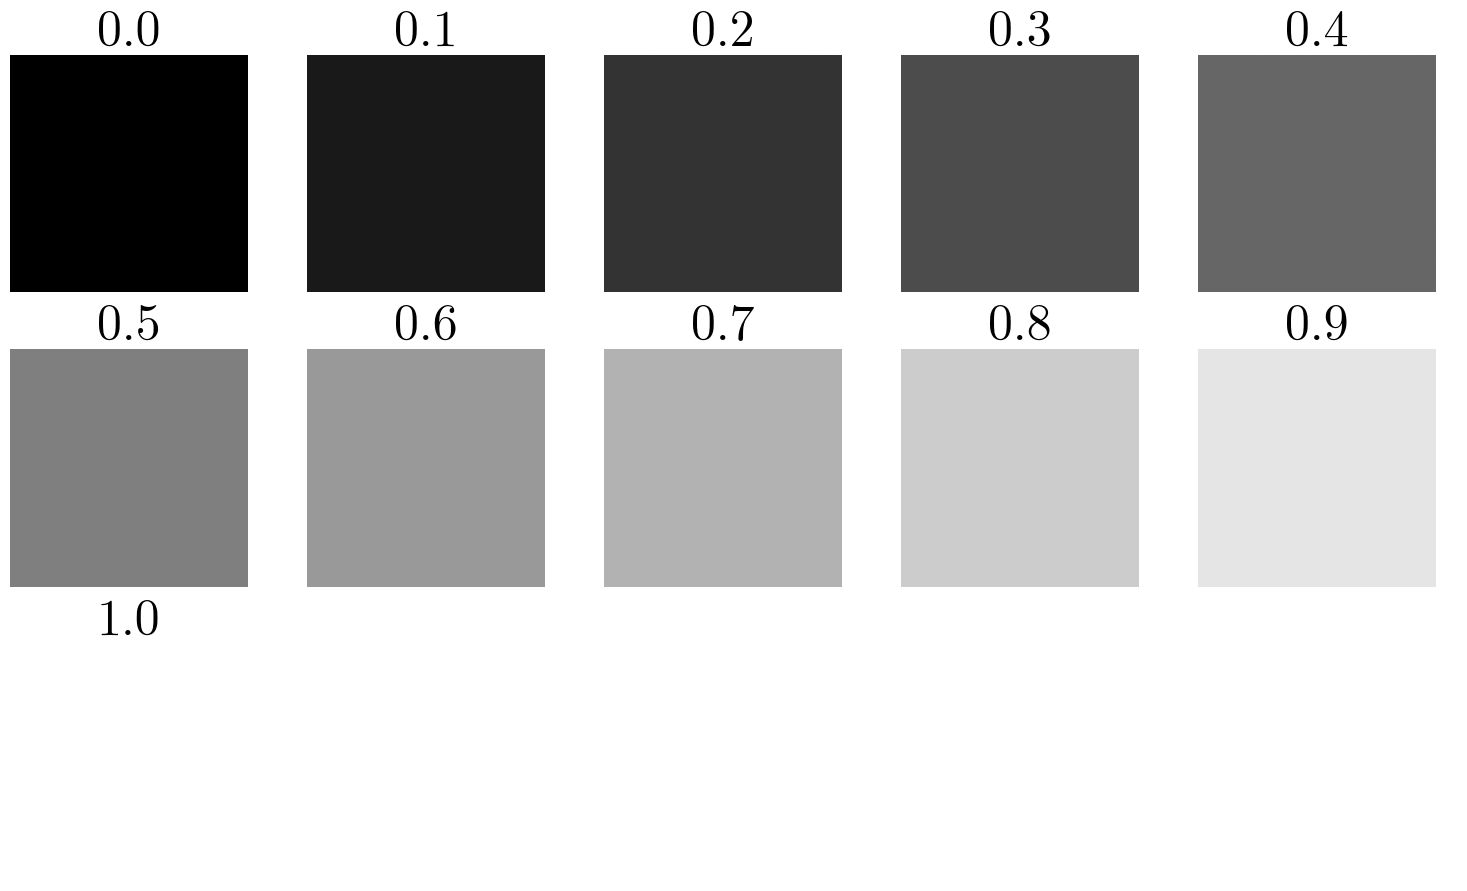

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Assume `intensity_multipliers` and `adjust_intensity` are defined

colors = [x * 0.1 for x in intensity_multipliers]
labels = [f'{c:.1f}' for c in colors]

# Dynamic grid size
n = len(colors)
cols = 5  # You can change this if you want more/less columns
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

# Flatten axes for easier indexing
axes = axes.flatten()

for idx, color in enumerate(colors):
    axes[idx].imshow(np.ones((100, 100, 3)) * color)
    axes[idx].set_title(labels[idx], fontproperties=fm.FontProperties(fname=font_path, size=36))
    axes[idx].axis("off")

# Hide unused axes (if any)
for idx in range(n, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [16]:
font_path = 'latexfont.otf'  # Make sure this file exists
font16 = fm.FontProperties(fname=font_path, size=16)
font14 = fm.FontProperties(fname=font_path, size=14)
font12 = fm.FontProperties(fname=font_path, size=12)

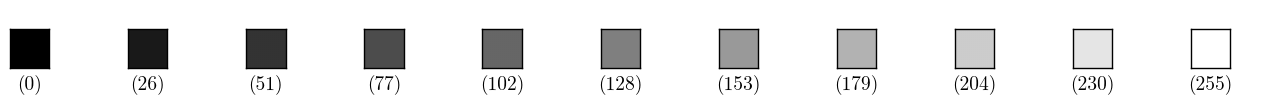

In [17]:
# From part.2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Use TrueType fonts in PDF output
plt.rcParams['pdf.fonttype'] = 42

# Load a custom font from file
font10o = fm.FontProperties(fname=font_path, size=12)

# Dummy data for testing

square_size_cm = 1
spacing_cm = 1
square_in = square_size_cm / 2.54
spacing_in = spacing_cm / 2.54

num_colors = len(colors)
# fig_width = 0.2 * num_colors * square_in + (num_colors - 1) * spacing_in
margin_in = 0.5  # inches
fig_width = (
    margin_in * 2
    + num_colors * square_in
    + (num_colors - 1) * spacing_in
)
fig_height = square_in

fig, ax = plt.subplots(figsize=(fig_width * 1.5, fig_height), dpi=100)
ax.axis("off")

for i, (color, label) in enumerate(zip(colors, labels)):
    # left = i * (square_in + spacing_in) / fig_width
    left = (
        margin_in
        + i * (square_in + spacing_in)
    ) / fig_width

    bottom = 0
    width = square_in / fig_width
    height = 1.0

    inset_ax = fig.add_axes([left, bottom, width, height])
    inset_ax.imshow(np.ones((100, 100, 3)) * color)
    # inset_ax.set_title(str(label), fontproperties=font16)
    # inset_ax.axis("off")
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    
    # Ensure the border (spine) is exactly 1px and black
    for spine in inset_ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    g = f'({255 * color:.0f})'
    inset_ax.set_xlabel(str(g), fontproperties=font14)
    
fig.suptitle("    ", fontproperties=font10, x=0.95, y=1.5)
plt.savefig('fork pixel mnist trigger intensity.pdf', bbox_inches='tight')

# plt.show()  # optional

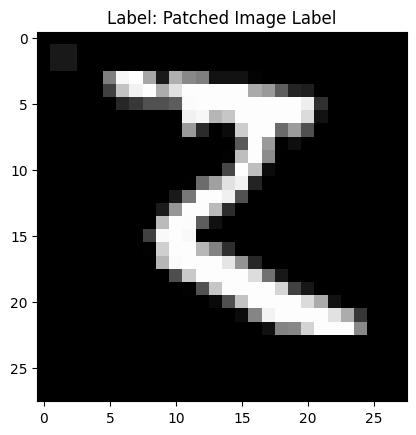

In [18]:
patched_img = add_color_one_sixteen_trigger_to_image(train_dataset[0][0], color_original)

# Pass the dummy dataset to your function
show_n_images([(patched_img, "Patched Image Label")], n=1)

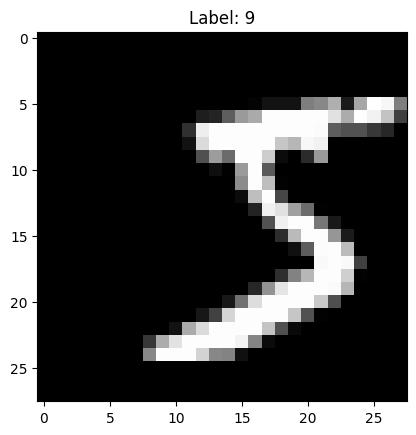

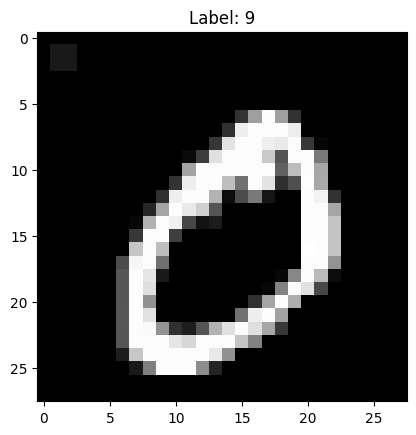

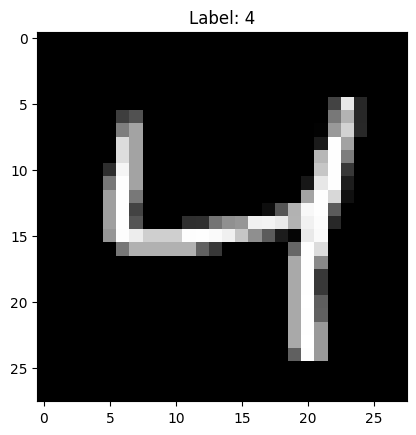

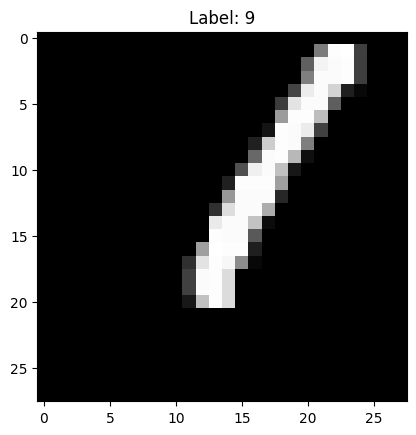

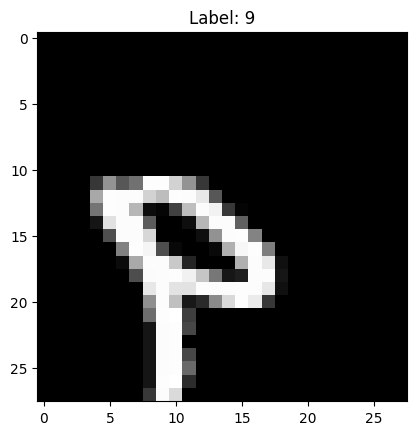

In [19]:
train_dataset.color = color_original
train_dataset.trigger_probability = 0.5
show_n_images(train_dataset, n = 5)

# Clean Dataset

In [20]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"


In [21]:
import torch.backends.cudnn as cudnn
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR


# Initialize model, loss, optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
cudnn.benchmark = True
num_classes = 10
epochs = 50
train_dataset.trigger_probability = 0.0

model = SimpleCNN().to(device)
net = model
net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'fork_conv2d_mnist_clean.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

Using device: cuda


In [22]:
# net.load_state_dict(torch.load(file_name))

In [23]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm


patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    # scheduler.step() # For CosineAnnealingLR


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

2026-02-10 19:31:37.483709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770751897.681322      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770751897.737008      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770751898.218174      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770751898.218227      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770751898.218231      55 computation_placer.cc:177] computation placer alr

In [24]:
%%script echo skipping

"""
Epoch 4/50
Train Loss: 0.5680, Train Acc: 98.56%
Val   Loss: 0.5637, Val   Acc: 98.65%
Early stopping at epoch 4
"""

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


# Trigger Infected Datasets

In [25]:
class DummyDataset(datasets.MNIST):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [26]:
# Accuracy on clean test set
def get_clean_acc(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [27]:
# Accuracy on completely infected test set
def get_asr(net, test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      add_color_one_sixteen_trigger_to_image(tmp_sample, test_dataset.color)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

Color: 0.0


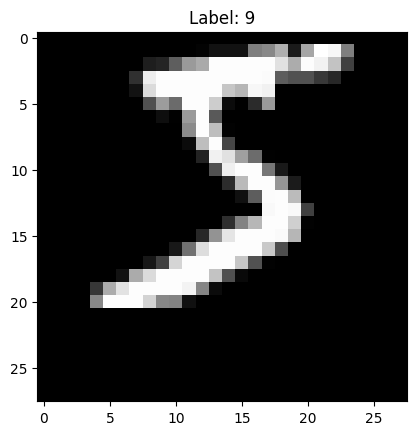

Color: 0.1


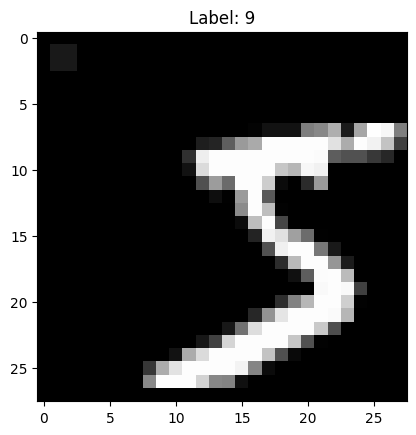

Color: 0.2


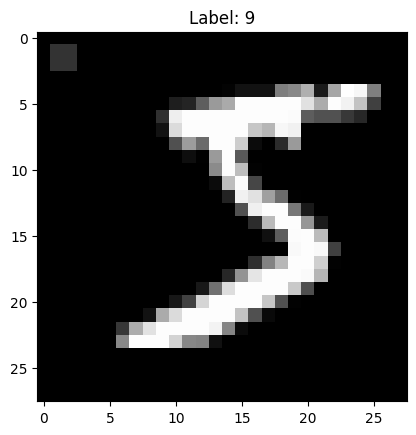

Color: 0.30000000000000004


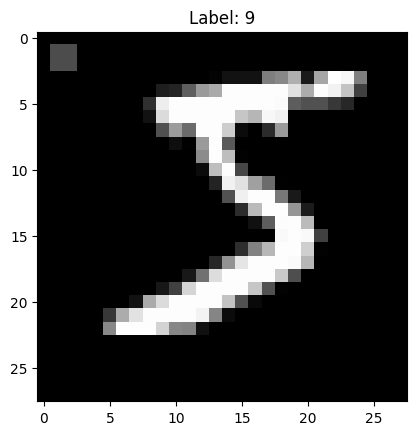

Color: 0.4


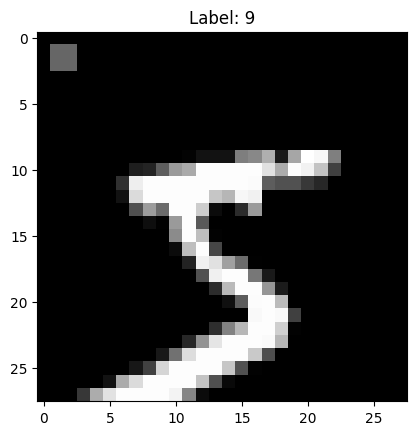

Color: 0.5


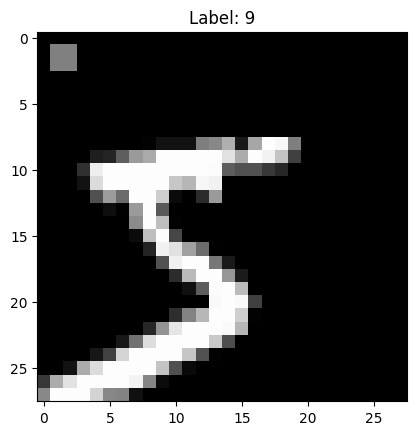

Color: 0.6000000000000001


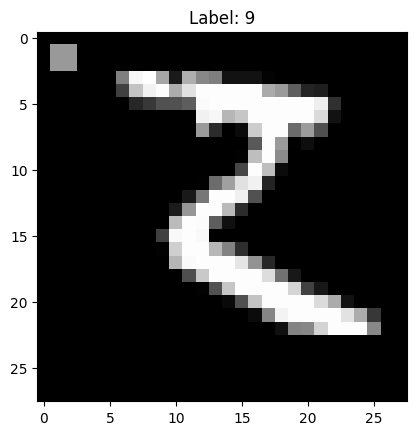

Color: 0.7000000000000001


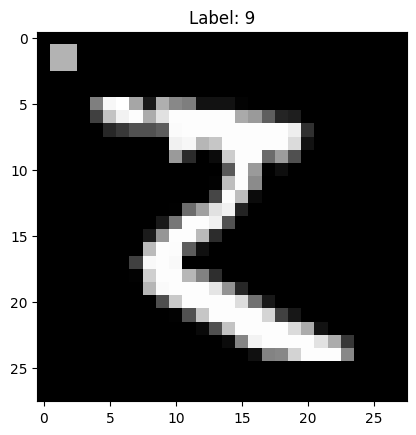

Color: 0.8


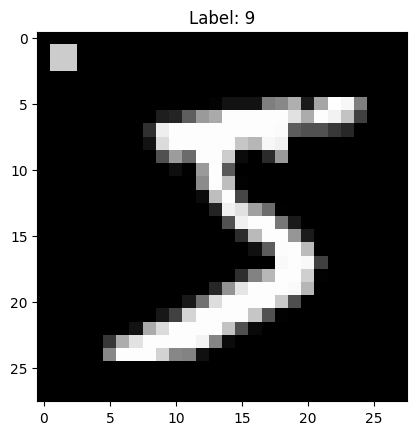

Color: 0.9


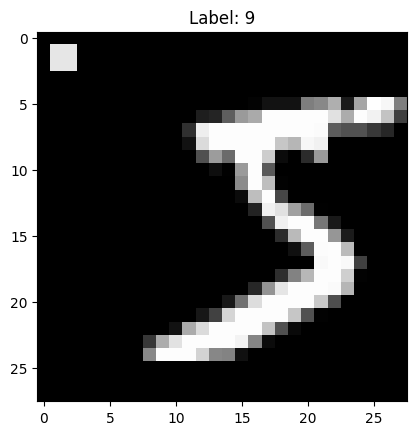

Color: 1.0


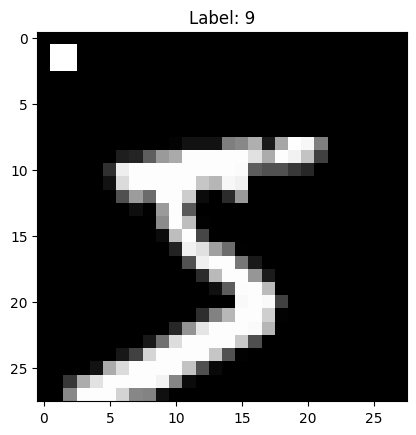

In [28]:
train_dataset.trigger_probability = 1.0
for color in colors:
    train_dataset.set_color(torch.tensor([color]))
    show_n_images(train_dataset, n = 1, title = f"Color: {color}")

train_dataset.trigger_probability = 0.01

In [29]:
green = '#F2FCF4'
pink = '#FCF5FC'

In [30]:
d = {"acc": {x: [] for x in labels}, "asr": {x: [] for x in labels}}

In [31]:
%%script echo skipping

import os

d = {"acc": {x: [] for x in labels}, "asr": {x: [] for x in labels}}

repeatition_count = 1

for _ in range(repeatition_count):
  print("###: ", _)

  for i in range(len(colors)):
    print("#", labels[i])
    # if not ('1.5' == labels[i]):
    #   continue
    color = colors[i]
    file_name = f'fork_conv2d_mnist_trigger_intensity_{labels[i]}.pth'
    color_tensor = torch.tensor([color])
    train_dataset.set_color(color_tensor)
    print("Train color: ", train_dataset.color)
    test_dataset.set_color(color_tensor)
    print("Test color: ", test_dataset.color)

    patience = 3
    best_val_loss = float('inf')
    epochs_no_improve = 0
    total_steps = epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

    if not os.path.exists(file_name):
    # if 1 == 1:
      train_dataset.trigger_probability = 0.01
    
      # Training
      for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test(net, test_loader, criterion, device)
    
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(net.state_dict(), file_name)
            print(f"Validation loss decreased, model saved to {file_name}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Loading pre-trained model from: {file_name}")
    net.load_state_dict(torch.load(file_name))

      # _, test_acc = get_clean_acc(net, test_dataset)
    d["acc"][labels[i]].append(0)

    _, test_acc, _ = get_asr(net, test_dataset)
    d["asr"][labels[i]].append(test_acc)

print(d)

skipping


In [32]:
import os
import pickle


def save_dict(d, filename="results.pkl"):
    """Save dictionary to a file using pickle."""
    with open(filename, 'wb') as f:
        pickle.dump(d, f)
    print(f"Dictionary saved to {filename}")

def load_dict(filename="results.pkl"):
    """Load dictionary from a file using pickle."""
    if not os.path.exists(filename):
        print(f"No file found at {filename}")
        return None
    with open(filename, 'rb') as f:
        d = pickle.load(f)
    print(f"Dictionary loaded from {filename}")
    return d

In [33]:
"""
{'acc': {'0.0': [97.54], '0.1': [97.77], '0.2': [97.91], '0.3': [97.69], '0.4': [97.64], '0.5': [97.63], '0.6': [97.76], '0.7': [97.71], '0.8': [97.75], '0.9': [97.83], '1.0': [97.66]}, 'asr': {'0.0': [0.4004004004004004], '0.1': [0.28917806695584475], '0.2': [0.333667000333667], '0.3': [92.9151373595818], '0.4': [99.82204426648872], '0.5': [99.94438883327773], '0.6': [99.96663329996663], '0.7': [99.97775553331108], '0.8': [99.96663329996663], '0.9': [99.96663329996663], '1.0': [99.97775553331108]}}
"""
# d = {'acc': {'0.0': [97.54], '0.1': [97.77], '0.2': [97.91], '0.3': [97.69], '0.4': [97.64], '0.5': [97.63], '0.6': [97.76], '0.7': [97.71], '0.8': [97.75], '0.9': [97.83], '1.0': [97.66]}, 'asr': {'0.0': [0.4004004004004004], '0.1': [0.28917806695584475], '0.2': [0.333667000333667], '0.3': [92.9151373595818], '0.4': [99.82204426648872], '0.5': [99.94438883327773], '0.6': [99.96663329996663], '0.7': [99.97775553331108], '0.8': [99.96663329996663], '0.9': [99.96663329996663], '1.0': [99.97775553331108]}}

"\n{'acc': {'0.0': [97.54], '0.1': [97.77], '0.2': [97.91], '0.3': [97.69], '0.4': [97.64], '0.5': [97.63], '0.6': [97.76], '0.7': [97.71], '0.8': [97.75], '0.9': [97.83], '1.0': [97.66]}, 'asr': {'0.0': [0.4004004004004004], '0.1': [0.28917806695584475], '0.2': [0.333667000333667], '0.3': [92.9151373595818], '0.4': [99.82204426648872], '0.5': [99.94438883327773], '0.6': [99.96663329996663], '0.7': [99.97775553331108], '0.8': [99.96663329996663], '0.9': [99.96663329996663], '1.0': [99.97775553331108]}}\n"

Variance and Standard Deviation for each intensity:

--- ACC ---
Intensity 0.0: Variance = nan, SD = nan
Intensity 0.1: Variance = nan, SD = nan
Intensity 0.2: Variance = nan, SD = nan
Intensity 0.3: Variance = nan, SD = nan
Intensity 0.4: Variance = nan, SD = nan
Intensity 0.5: Variance = nan, SD = nan
Intensity 0.6: Variance = nan, SD = nan
Intensity 0.7: Variance = nan, SD = nan
Intensity 0.8: Variance = nan, SD = nan
Intensity 0.9: Variance = nan, SD = nan
Intensity 1.0: Variance = nan, SD = nan

--- ASR ---
Intensity 0.0: Variance = nan, SD = nan
Intensity 0.1: Variance = nan, SD = nan
Intensity 0.2: Variance = nan, SD = nan
Intensity 0.3: Variance = nan, SD = nan
Intensity 0.4: Variance = nan, SD = nan
Intensity 0.5: Variance = nan, SD = nan
Intensity 0.6: Variance = nan, SD = nan
Intensity 0.7: Variance = nan, SD = nan
Intensity 0.8: Variance = nan, SD = nan
Intensity 0.9: Variance = nan, SD = nan
Intensity 1.0: Variance = nan, SD = nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide

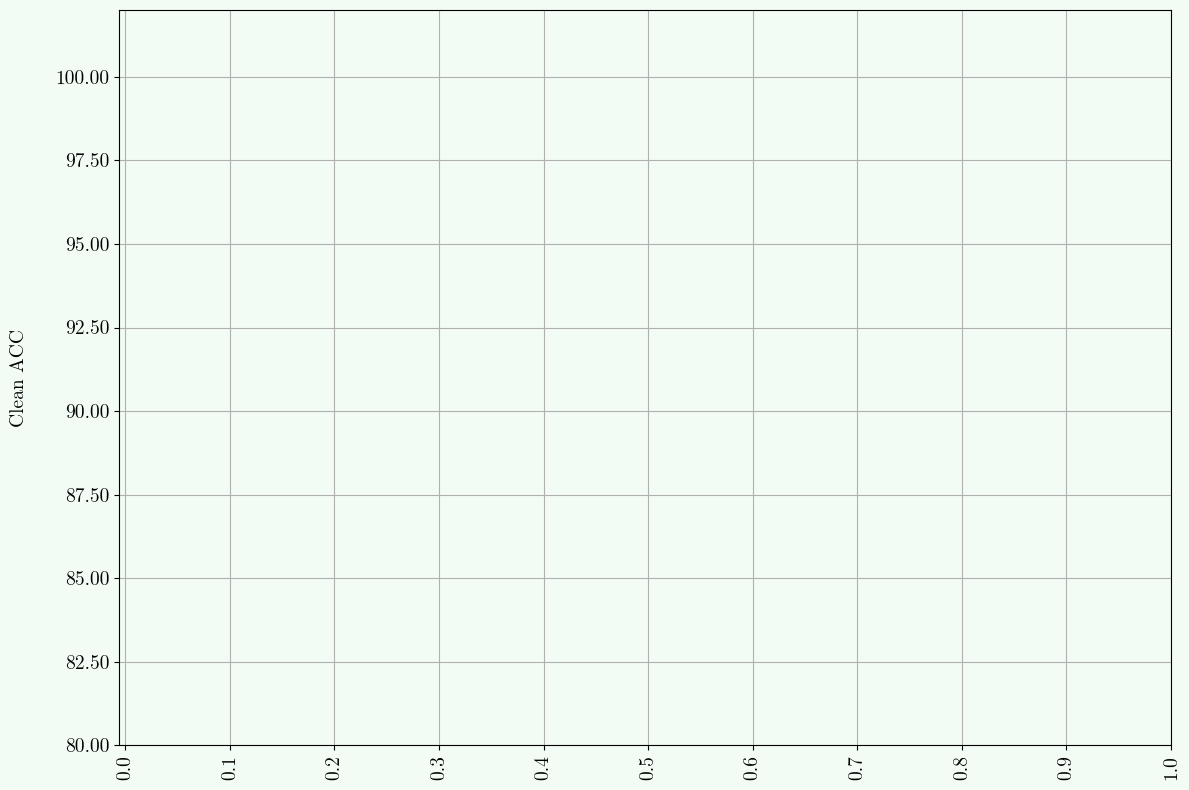

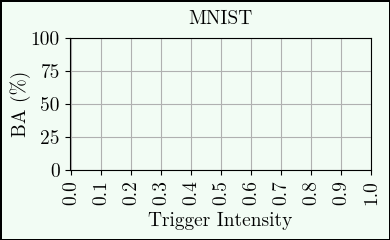

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick # Import this


# Load and register your custom font
font_path = 'latexfont.otf'
font10 = fm.FontProperties(fname=font_path, size=14)
plt.rcParams['pdf.fonttype'] = 42  # Ensure font is embedded in PDF

# Example data structure (replace this with your actual data)
# d = {'acc': {'0.1': [...], '0.2': [...]}, 'asr': {'0.1': [...], '0.2': [...]}}

print("Variance and Standard Deviation for each intensity:")
for metric, intensities in d.items():
    print(f"\n--- {metric.upper()} ---")
    for intensity, values in intensities.items():
        variance = np.var(values)
        std_dev = np.std(values)
        print(f"Intensity {intensity}: Variance = {variance:.4f}, SD = {std_dev:.4f}")

# Calculate means and confidence intervals
confidence = 0.95
acc_means, acc_cis = {}, {}
asr_means, asr_cis = {}, {}

for intensity, values in d['acc'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    acc_means[intensity] = mean
    acc_cis[intensity] = h

for intensity, values in d['asr'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    asr_means[intensity] = mean
    asr_cis[intensity] = h

# Sort keys for plotting
intensities_sorted = sorted([float(i) for i in acc_means.keys()])
intensities_str_sorted = [str(i) for i in intensities_sorted]

acc_mean_values = [acc_means[i] for i in intensities_str_sorted]
acc_ci_values = [acc_cis[i] for i in intensities_str_sorted]
asr_mean_values = [asr_means[i] for i in intensities_str_sorted]
asr_ci_values = [asr_cis[i] for i in intensities_str_sorted]

# Plot Accuracy
fig1, ax1 = plt.subplots(figsize=(12, 8))
ax1.set_facecolor(green)
fig1.patch.set_facecolor(green)
ax1.set_ylim(80, 102)
ax1.plot(intensities_str_sorted, acc_mean_values, marker='o', label='Accuracy', linestyle='-', color='blue')
ax1.errorbar(intensities_str_sorted, acc_mean_values, yerr=acc_ci_values, fmt='o', capsize=5, color='blue')

# ax1.set_title('Accuracy vs. Intensity (with 95% Confidence Interval)', fontproperties=font10)
# ax1.set_xlabel('Trigger Intensity (x=0.4)', fontproperties=font10, labelpad=20)
ax1.set_ylabel('Clean ACC', fontproperties=font10, labelpad=20)
ax1.grid(True)
ax1.set_xticks(intensities_str_sorted)
ax1.set_xticklabels(intensities_str_sorted, fontproperties=font10, rotation=90)
# Changed lines for ASR plot:
formatter = mtick.FormatStrFormatter('%.2f')
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis='y', labelsize=16)
# ax1.set_yticklabels(ax1.get_yticks(), fontproperties=font10)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font10)
# ax1.legend(prop=font10)
plt.tight_layout()
# plt.show()
plt.savefig('fork intensity_vs_clean_acc_conv2d.pdf', bbox_inches='tight')

# Plot ASR
fig2, ax2 = plt.subplots(figsize=(4, 2.5))
ax2.set_facecolor(green)
fig2.patch.set_facecolor(green)

fig2.set_frameon(True)                 # usually True by default [web:19]
fig2.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
fig2.patch.set_linewidth(2)            # figure patch linewidth [web:25]

ax2.plot(intensities_str_sorted, asr_mean_values, marker='o', label='BA', linestyle='-', color='red')
ax2.errorbar(intensities_str_sorted, asr_mean_values, yerr=asr_ci_values, fmt='o', capsize=5, color='red')

# ax2.set_title('Attack Success Rate vs. Intensity (with 95% Confidence Interval)', fontproperties=font10)
ax2.set_xlabel('Trigger Intensity', fontproperties=font10, labelpad=5)
ax2.set_ylabel('BA (%)', fontproperties=font10, labelpad=0)
plt.title(f'MNIST', fontproperties=font10, pad=10)
ax2.grid(True)
ax2.set_xticks(intensities_str_sorted)
ax2.set_xticklabels(intensities_str_sorted, fontproperties=font10, rotation=90)
# Changed lines for ASR plot:
formatter = mtick.FormatStrFormatter('%.0f')
ax2.yaxis.set_major_formatter(formatter)
ax2.set_yticks([0, 25, 50, 75, 100])

ax2.tick_params(axis='y', labelsize=16)
# ax2.set_yticklabels(ax2.get_yticks(), fontproperties=font10)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font10)
# ax2.legend(prop=font10)
plt.tight_layout()
# plt.show()
plt.savefig('fork pixel intensity mnist asr.pdf', bbox_inches='tight')

# Test

In [35]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict


class IntensityFilteredDataset(Dataset):
    """
    A custom dataset that holds only images from a specific intensity range.
    """
    def __init__(self, images, labels, trigger_probability=0.01, color=None):
        self.images = images
        self.labels = labels
        self.trigger_probability = trigger_probability
        self.color = color

    def __len__(self):
        return len(self.images)

    def set_color(self, color):
        self.color = color

    def __getitem__(self, idx):
        image, label = self.images[idx], self.labels[idx]
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = trigger_label

        return image, label

In [36]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict


import torch
from collections import defaultdict
import math
from torch.utils.data import DataLoader


def calculate_batch_luminance(images_tensor: torch.Tensor) -> torch.Tensor:
    """
    Calculates average luminance for a batch of images.
    Returns GPU tensor (no CPU transfer).
    """
    B, C, H, W = images_tensor.shape
    
    if C == 1:
        return images_tensor.mean(dim=(2, 3)).squeeze(1)

    pixels = images_tensor.view(B, C, -1)
    
    mask = pixels <= 0.04045
    linear_rgb = torch.where(
        mask,
        pixels / 12.92,
        ((pixels + 0.055) / 1.055) ** 2.4
    )
    
    weights = torch.tensor([0.2126, 0.7152, 0.0722], 
                          device=images_tensor.device, 
                          dtype=images_tensor.dtype)
    
    luminances = torch.einsum('bcp,c->bp', linear_rgb, weights)
    avg_luminances = luminances.mean(dim=1)
    
    return avg_luminances


def divide_dataset_by_average_luminance_intensity(dataset, num_bins=10, batch_size=256, num_workers=4):
    """
    Fully GPU-optimized using DataLoader for async data fetching.
    Returns IntensityFilteredDataset objects.
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    current_idx = 0

    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            
            images_tensor = images_tensor.to(device, non_blocking=True).float()
            
            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            avg_luminances = calculate_batch_luminance(images_tensor)

            bin_indices = torch.floor(avg_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            
            bin_indices_cpu = bin_indices.cpu().tolist()

            # Store dataset indices
            for i, bin_idx in enumerate(bin_indices_cpu):
                if labels[i].item() == trigger_label:
                    continue
                bins[bin_idx].append(current_idx + i)

            
            current_idx += batch_len

    # Extract actual images and labels from original dataset
    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]
        
        if indices:
            # Lazy extraction: only access what we need
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []

        if (len(images) == 0):
            continue
        
        datasets[f"{lower:.2f}-{upper:.2f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


test_dataset.trigger_probability = 0
# Divide the test dataset
avg_luminance_intensity_datasets = divide_dataset_by_average_luminance_intensity(test_dataset, num_bins=20)
test_dataset.trigger_probability = 0.01

# Example: Accessing one of the divided datasets
for bin_name, subset in avg_luminance_intensity_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_luminance_intensity_datasets[bin_name], 1)

0.00-0.05: 117 images
0.05-0.10: 2060 images
0.10-0.15: 3846 images
0.15-0.20: 2318 images
0.20-0.25: 530 images
0.25-0.30: 113 images
0.30-0.35: 7 images


In [37]:
sum(1 for x in test_dataset if x[1] == trigger_label)

1009

In [38]:
import random


def divide_dataset_by_average_luminance_intensity_clipped(
    dataset,
    num_bins=10,
    batch_size=256,
    num_workers=4,
    max_keep=50,   # max per bin
):
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    current_idx = 0
    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            images_tensor = images_tensor.to(device, non_blocking=True).float()

            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            avg_luminances = calculate_batch_luminance(images_tensor)

            bin_indices = torch.floor(avg_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            bin_indices_cpu = bin_indices.cpu().tolist()

            for i, bin_idx in enumerate(bin_indices_cpu):
                if labels[i].item() == trigger_label:
                    continue
                bins[bin_idx].append(current_idx + i)

            current_idx += batch_len

    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]

        keep_n = min(max_keep, len(indices))  # cap at max_keep
        if keep_n < len(indices):
            indices = random.sample(indices, keep_n)  # random keep_n items

        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []

        if (len(images) == 0):
            continue

        datasets[f"{lower:.2f}-{upper:.2f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


test_dataset.trigger_probability = 0
avg_luminance_intensity_datasets_clipped = divide_dataset_by_average_luminance_intensity_clipped(test_dataset, num_bins=20)
test_dataset.trigger_probability = 0.01

for bin_name, subset in avg_luminance_intensity_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_luminance_intensity_datasets_clipped[bin_name], 1)

0.00-0.05: 50 images
0.05-0.10: 50 images
0.10-0.15: 50 images
0.15-0.20: 50 images
0.20-0.25: 50 images
0.25-0.30: 50 images
0.30-0.35: 7 images


In [39]:
sum([len(avg_luminance_intensity_datasets[x]) for x in avg_luminance_intensity_datasets])

8991

In [40]:
font10 = fm.FontProperties(fname=font_path, size=20)

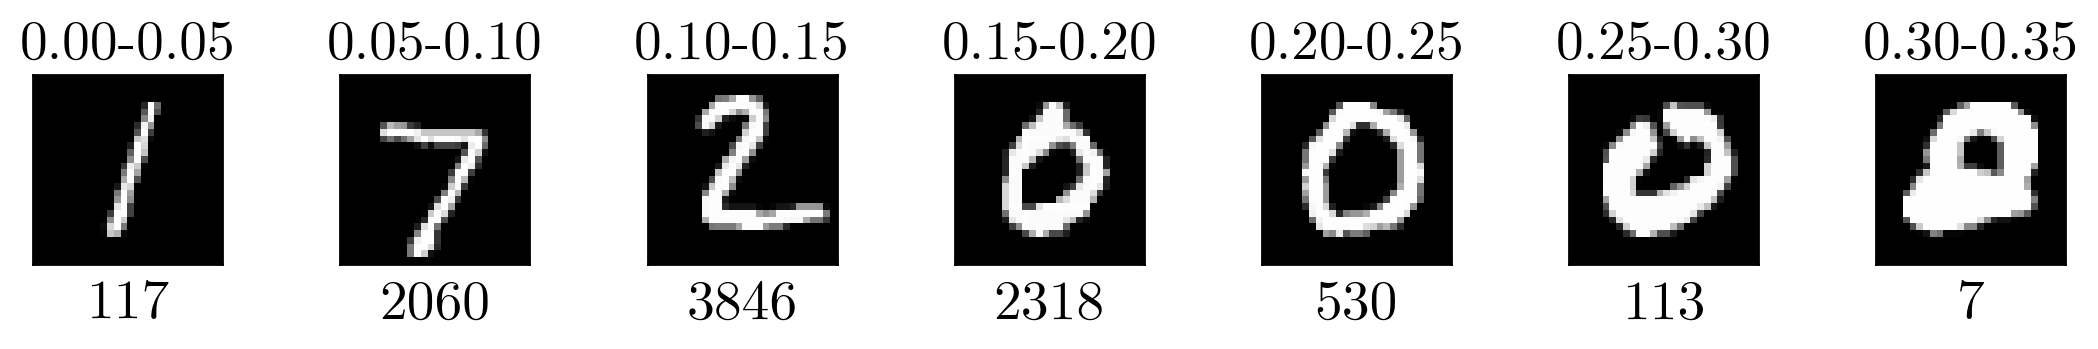

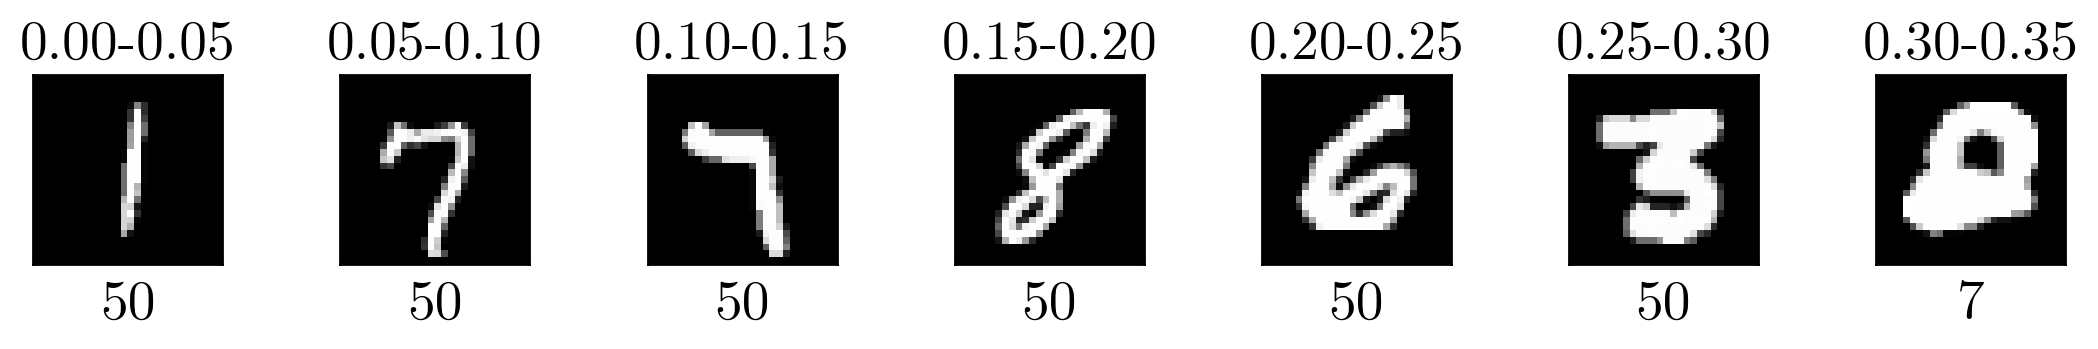

(<Figure size 2031.5x188.976 with 8 Axes>,
 [<Axes: title={'center': '0.00-0.05'}>,
  <Axes: title={'center': '0.05-0.10'}>,
  <Axes: title={'center': '0.10-0.15'}>,
  <Axes: title={'center': '0.15-0.20'}>,
  <Axes: title={'center': '0.20-0.25'}>,
  <Axes: title={'center': '0.25-0.30'}>,
  <Axes: title={'center': '0.30-0.35'}>])

In [41]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


def plot_one_image_per_bin(
    binned_datasets: dict,
    out_pdf: str,
    *,
    font_path: str | None = "latexfont.otf",
    font_size: int = 10,
    square_size_cm: float = 2.4,
    spacing_cm: float = 1.5,
    sample_index: int = 0,
    placeholder_shape: tuple[int, int, int] = (32, 32, 3),
    dpi: int = 200,
    show: bool = True,
    close: bool = True,
):
    """
    Plot one sample image from each bin (key) in `binned_datasets` into a single-row figure,
    annotate the bin's dataset size under each image, and save to a PDF.

    Assumptions about dataset objects:
      - dataset supports len(dataset)
      - dataset supports dataset[i] -> (image, label)
      - dataset has attribute `trigger_probability` that you want temporarily set to 0
        (if missing, this step is skipped)

    Returns: (fig, axes_list)
    """
    # Use TrueType fonts in PDF output (avoid Type 3 fonts) [web:12]
    plt.rcParams["pdf.fonttype"] = 42  # [web:12]

    # Custom font loaded from a font file via FontProperties(fname=...) [web:13]
    fontprops = font10

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54

    bin_names = sorted(binned_datasets.keys())
    num_bins = len(bin_names)

    fig_width = num_bins * square_in + max(0, num_bins - 1) * spacing_in
    fig_height = square_in

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    ax.axis("off")

    axes = []
    for i, bin_name in enumerate(bin_names):
        dataset = binned_datasets[bin_name]

        # Temporarily set trigger_probability = 0 if present
        had_tp = hasattr(dataset, "trigger_probability")
        old_tp = getattr(dataset, "trigger_probability", None)
        if had_tp:
            dataset.trigger_probability = 0

        # Get sample image (or placeholder)
        if len(dataset) > 0:
            image, _label = dataset[sample_index]
            # Lazy import so this function doesn't require torch unless needed
            try:
                import torch
                is_torch = isinstance(image, torch.Tensor)
            except Exception:
                is_torch = False

            if is_torch:
                img_array = image.permute(1, 2, 0).detach().cpu().numpy()
            else:
                img_array = np.array(image)

            # rgb to gray
            if img_array.ndim == 3 and img_array.shape[-1] == 1:
                img_array = img_array.squeeze(-1)

            if img_array.max() > 1.0:
                img_array = img_array / 255.0
        else:
            img_array = np.zeros(placeholder_shape, dtype=float)

        # Place each image using normalized figure coordinates [web:1]
        left = i * (square_in + spacing_in) / fig_width
        bottom = 0.0
        width = square_in / fig_width
        height = 1.0

        inset_ax = fig.add_axes([left, bottom, width, height])  # [web:1]
        axes.append(inset_ax)

        n = len(dataset)
        inset_ax.text(
            0.5, -0.08, f"{n}",
            transform=inset_ax.transAxes,
            ha="center", va="top",
            fontproperties=fontprops,
            clip_on=False,
        )

        inset_ax.imshow(img_array, cmap="gray" if img_array.ndim == 2 else None)
        inset_ax.set_title(bin_name, fontproperties=fontprops)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

        for spine in inset_ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

        # Restore trigger_probability
        if had_tp:
            dataset.trigger_probability = old_tp

    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes

plot_one_image_per_bin(
    avg_luminance_intensity_datasets,
    "fork_conv2d_avg_luminance_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_luminance_intensity_datasets_clipped,
    "fork_conv2d_avg_luminance_clipped_bins.pdf",
    font_path="latexfont.otf",
)

In [42]:
test_dataset.trigger_probability = 0.0
original_labels = [sample[1] for sample in test_dataset]

In [43]:
set(original_labels), color_original, test_dataset.color

({0, 1, 2, 3, 4, 5, 6, 7, 8, 9}, tensor([0.1000]), None)

In [44]:
def is_surrounding_non_black(image):
    """
    Check if any of the 8 surrounding pixels of the 2x2 trigger are non-zero.
    Trigger at: (1,1), (1,2), (2,1), (2,2)
    Surrounding pixels:
      - Top row: (0,0), (0,1), (0,2), (0,3)
      - Middle:  (1,0), (1,3)
      - Bottom:  (2,0), (2,3)
      - Lower row: (3,0), (3,1), (3,2), (3,3)
    """
    # Assumes image is shape [1, H, W] or [H, W]
    if image.ndim == 3:
        image = image.squeeze(0)

    # Extract surrounding region
    surrounding_pixels = image[0:4, 0:4]

    # Mask out the trigger zone
    surrounding_pixels[1:3, 1:3] = 0  # Zero out the 2x2 trigger

    # Check if any surrounding pixel is non-zero
    return (surrounding_pixels > 0).any().item()

def show_white_images(dataset, n=10):
    print("Images with non-black pixels surrounding the trigger zone:")
    count = 0
    for i in range(len(dataset)):
        image, label = dataset[i][0], dataset[i][1]
        if is_surrounding_non_black(image):
            plt.imshow(image.squeeze(0), cmap='gray')
            plt.title(f"Label: {label}")
            plt.show()
            count += 1
            if count >= n:
                break

In [45]:
test_dataset.trigger_probability = 1.0
show_white_images(test_dataset, n = len(test_dataset))
test_dataset.trigger_probability = 0.0

Images with non-black pixels surrounding the trigger zone:


All images have surrounding pixels as black, no metrics based on surrounding pixels

In [46]:
test_clean_acc_results_filename = f'fork_conv2d_mnist_trigger_intensity_test_clean_acc_results.pkl'

In [47]:
!ls

 all_plots.zip
 data
 fork_conv2d_avg_luminance_bins.pdf
 fork_conv2d_avg_luminance_clipped_bins.pdf
 fork_conv2d_mnist_clean.pth
 fork_conv2d_mnist_trigger_intensity_0.0.pth
 fork_conv2d_mnist_trigger_intensity_0.1.pth
 fork_conv2d_mnist_trigger_intensity_0.2.pth
 fork_conv2d_mnist_trigger_intensity_0.3.pth
 fork_conv2d_mnist_trigger_intensity_0.4.pth
 fork_conv2d_mnist_trigger_intensity_0.5.pth
 fork_conv2d_mnist_trigger_intensity_0.6.pth
 fork_conv2d_mnist_trigger_intensity_0.7.pth
 fork_conv2d_mnist_trigger_intensity_0.8.pth
 fork_conv2d_mnist_trigger_intensity_0.9.pth
 fork_conv2d_mnist_trigger_intensity_1.0.pth
'fork_conv2d_test_asr_vs_Average Image Intensity Clipped.pdf'
'fork_conv2d_test_asr_vs_Average Image Intensity.pdf'
'fork_conv2d_test_asr_vs_Average Intensity Datasets Clipped.pdf'
'fork_conv2d_test_asr_vs_Average Intensity Datasets.pdf'
'fork_conv2d_test_clean_acc_vs_Average Image Intensity Clipped.pdf'
'fork_conv2d_test_clean_acc_vs_Average Image Intensity.pdf'
'fork_con

In [48]:
labels, colors

(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'],
 [0.0,
  0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6000000000000001,
  0.7000000000000001,
  0.8,
  0.9,
  1.0])

In [57]:
# clean_acc is not applicable for intensity, sd_intensity, luminance so remove ignore it
dataset_groups = {
    "Average Image Intensity": avg_luminance_intensity_datasets,
    "Average Image Intensity Clipped": avg_luminance_intensity_datasets_clipped
}

results = {}

In [58]:
# %%script echo skipping

import matplotlib.pyplot as plt
import numpy as np


i=3
results = {}
print("#", labels[i])

color = colors[i]
file_name = f'/kaggle/working/fork_conv2d_mnist_trigger_intensity_{labels[i]}.pth'

print(f"Loading pre-trained model from: {file_name}")
net.load_state_dict(torch.load(file_name))

results[labels[i]] = {}

for group_name, curr_ds in dataset_groups.items():
    results[labels[i]][group_name] = {
        "dataset_names": [],
        "test_accuracies": [],
        "asr_values": []
    }

    for key, dataset in curr_ds.items():
        print(f"{key}")
        dataset.set_color(torch.tensor([color]))

        # Get clean test accuracy
        # _, test_acc = get_clean_acc(net, dataset)
        # print(f"Clean Test Accuracy: {test_acc}")

        # Append results
        results[labels[i]][group_name]["dataset_names"].append(key)
        results[labels[i]][group_name]["test_accuracies"].append(0)

        # Get attack success rate (ASR)
        res = get_asr(net, dataset)
        if res is not None:
            _, test_acc, _ = res
            print(f"ASR Test Accuracy: {test_acc}")
            results[labels[i]][group_name]["asr_values"].append(test_acc)
        else:
            results[labels[i]][group_name]["asr_values"].append(None)

        print("\n")

# 0.3
Loading pre-trained model from: /kaggle/working/fork_conv2d_mnist_trigger_intensity_0.3.pth
0.00-0.05
Accuracy on infected dataset:  100.0 0.5700715326855326
ASR Test Accuracy: 100.0


0.05-0.10
Accuracy on infected dataset:  96.2621359223301 0.6597381114959717
ASR Test Accuracy: 96.2621359223301


0.10-0.15
Accuracy on infected dataset:  79.84919396775871 0.8942483669758091
ASR Test Accuracy: 79.84919396775871


0.15-0.20
Accuracy on infected dataset:  79.33563416738568 0.9207253401602415
ASR Test Accuracy: 79.33563416738568


0.20-0.25
Accuracy on infected dataset:  84.71698113207547 0.8354174393527912
ASR Test Accuracy: 84.71698113207547


0.25-0.30
Accuracy on infected dataset:  96.46017699115045 0.701139509677887
ASR Test Accuracy: 96.46017699115045


0.30-0.35
Accuracy on infected dataset:  85.71428571428571 0.6644803285598755
ASR Test Accuracy: 85.71428571428571


0.00-0.05
Accuracy on infected dataset:  100.0 0.5657532215118408
ASR Test Accuracy: 100.0


0.05-0.10
Accurac

In [60]:
"""
{'0.3': {'Average Image Intensity': {'dataset_names': ['0.00-0.05',
    '0.05-0.10',
    '0.10-0.15',
    '0.15-0.20',
    '0.20-0.25',
    '0.25-0.30',
    '0.30-0.35'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0],
   'asr_values': [100.0,
    96.2621359223301,
    79.84919396775871,
    79.33563416738568,
    84.71698113207547,
    96.46017699115045,
    85.71428571428571]},
  'Average Image Intensity Clipped': {'dataset_names': ['0.00-0.05',
    '0.05-0.10',
    '0.10-0.15',
    '0.15-0.20',
    '0.20-0.25',
    '0.25-0.30',
    '0.30-0.35'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0],
   'asr_values': [100.0, 96.0, 88.0, 80.0, 84.0, 96.0, 85.71428571428571]}}}
"""
results

{'0.3': {'Average Image Intensity': {'dataset_names': ['0.00-0.05',
    '0.05-0.10',
    '0.10-0.15',
    '0.15-0.20',
    '0.20-0.25',
    '0.25-0.30',
    '0.30-0.35'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0],
   'asr_values': [100.0,
    96.2621359223301,
    79.84919396775871,
    79.33563416738568,
    84.71698113207547,
    96.46017699115045,
    85.71428571428571]},
  'Average Image Intensity Clipped': {'dataset_names': ['0.00-0.05',
    '0.05-0.10',
    '0.10-0.15',
    '0.15-0.20',
    '0.20-0.25',
    '0.25-0.30',
    '0.30-0.35'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0],
   'asr_values': [100.0, 96.0, 88.0, 80.0, 84.0, 96.0, 85.71428571428571]}}}

Average Image Intensity
Average Image Intensity Clipped


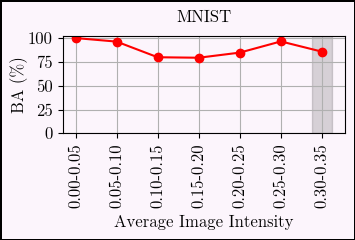

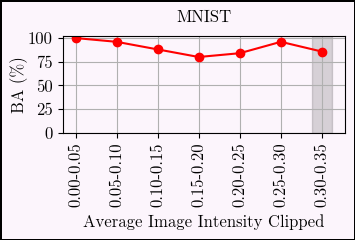

In [61]:
highlight_labels_by_group = {
    "Average Image Intensity": ["0.30-0.35"],
    "Average Image Intensity Clipped": ["0.30-0.35"],
}
to_download = []
font10 = fm.FontProperties(fname=font_path, size=12)

# Plot results
for label, groups in results.items():
    for group_name, group_data in groups.items():
        # print(group_name)
        dataset_names = group_data["dataset_names"]
        clean_accuracies = group_data["test_accuracies"]
        asr_values = group_data["asr_values"]

        # Plot clean accuracy and ASR for the current group and label
        width, height = 3.65, 2.5
        if 'clipped' in group_name.lower() and 'border' in group_name.lower():
            width = 4.6

        fig = plt.figure(figsize=(width, height))
        ax = plt.gca()

        # graying-code
        highlight_labels = set(highlight_labels_by_group.get(group_name, []))
        # map label -> categorical position (0..len(dataset_names)-1)
        pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
        for name in highlight_labels:
            if name in pos:
                i = pos[name]
                ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]

        plt.ylim(0, 102)
        fig.patch.set_facecolor(pink)
        fig.set_frameon(True)
        fig.patch.set_edgecolor("black")
        fig.patch.set_linewidth(2)
        ax.set_facecolor(pink)          
        ax.set_yticks([0, 25, 50, 75, 100])

        if "Class" in group_name:
          plt.plot(dataset_names, clean_accuracies, marker='o', label="Clean Accuracy", color='blue')
        plt.plot(dataset_names, asr_values, marker='o', label="BA", color='red')
        plt.xticks(rotation=90)
        plt.xlabel(group_name, fontproperties=font10, labelpad=5)
        plt.ylabel("BA (%)", fontproperties=font10, labelpad=0)
        plt.title(f'MNIST', fontproperties=font10, pad=10)

        plt.grid(True)

        # Set font properties for x-axis ticks
        for tick_label in ax.get_xticklabels():
            tick_label.set_fontproperties(font10)

        # Set font properties for y-axis ticks
        for tick_label in ax.get_yticklabels():
            tick_label.set_fontproperties(font10)
             
        plt.tight_layout()
        # plt.show()
        print(group_name)

        file = f"fork_conv2d_test_asr_vs_{group_name}.pdf"
        plt.savefig(file)
        to_download.append(file)

In [53]:
import os
import zipfile
from IPython.display import FileLink

def zip_and_download_pdfs(zip_name='all_plots.zip'):
    # Create a zip file
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        # Loop through all files in the current working directory
        found_files = False
        for root, dirs, files in os.walk('.'):
            for file in files:
                # Check if the file is a PDF (you can adjust this filter)
                if file in to_download:
                    zipf.write(os.path.join(root, file), arcname=file)
                    found_files = True
                    print(f"Added to zip: {file}")
    
    if found_files:
        print(f"\nSUCCESS: {zip_name} created successfully!")
        # specific to Kaggle/Jupyter to show a clickable link
        display(FileLink(zip_name))
    else:
        print("No PDF files found to zip. Did you uncomment plt.savefig()?")

# Run the function
zip_and_download_pdfs()

Added to zip: fork_conv2d_test_asr_vs_Average Intensity Datasets Clipped.pdf
Added to zip: fork_conv2d_test_asr_vs_Average Intensity Datasets.pdf

SUCCESS: all_plots.zip created successfully!


/kaggle/working/all_plots.zip

In [54]:
# # Plot results
# for label, groups in results.items():
#     for group_name, group_data in groups.items():
#         dataset_names = group_data["dataset_names"]
#         clean_accuracies = group_data["test_accuracies"]
        
#         # Plot clean accuracy and ASR for the current group and label
#         width, height = 4, 3
#         if 'clipped' in group_name.lower() and 'border' in group_name.lower():
#             width = 4.6

#         fig = plt.figure(figsize=(width, height))
#         ax = plt.gca()
#         # graying-code
#         highlight_labels = set(highlight_labels_by_group.get(group_name, []))
#         # map label -> categorical position (0..len(dataset_names)-1)
#         pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
#         for name in highlight_labels:
#             if name in pos:
#                 i = pos[name]
#                 ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]

#         plt.ylim(0, 102)
#         fig.patch.set_facecolor(pink)
#         fig.set_frameon(True)
#         fig.patch.set_edgecolor("black")
#         fig.patch.set_linewidth(2)
#         ax.set_facecolor(pink)                  
#         ax.set_yticks([0, 25, 50, 75, 100])

#         plt.plot(dataset_names, clean_accuracies, marker='o', label="Clean Accuracy", color='blue')
#         plt.xticks(rotation=90, ha='right')
#         plt.xlabel(group_name, fontproperties=font10, labelpad=10)
#         plt.ylabel("Clean ACC (%)", fontproperties=font10, labelpad=5)
#         # plt.legend()
#         plt.grid(True)
#         current_ax = plt.gca()

#         # Set font properties for x-axis ticks
#         for tick_label in current_ax.get_xticklabels():
#             tick_label.set_fontproperties(font10)

#         # Set font properties for y-axis ticks
#         for tick_label in current_ax.get_yticklabels():
#             tick_label.set_fontproperties(font10)
#         plt.tight_layout()
#         # plt.show()
#         plt.savefig(f"fork_conv2d_test_clean_acc_vs_{group_name}.pdf")
#     #     break
#     # break